# 🏆 บทที่ 12 (Capstone) — Zonal Statistics รายลุ่มน้ำ และการประยุกต์ใช้
### หลักสูตรแลปเรดาร์ตรวจอากาศด้วย Py-ART และ wradlib

**ระดับ:** ขั้นสูง (บทสรุปบูรณาการ)  |  **ต้องมีก่อน:** รันบทที่ 00 แล้ว (ใช้แนวคิดจากบท 03, 06, 08, 11)

บทนี้บูรณาการทั้งหลักสูตร: นำ **ฝนจากเรดาร์** มาสรุปเป็นสถิติ **รายลุ่มน้ำย่อย** แล้วต่อยอดสู่ **10 กรณีการประยุกต์ใช้จริง** ด้านอุทกวิทยา การเตือนภัย คุณภาพข้อมูล และการทำรายงาน

**เส้นเรื่องของบท (ร้อยเรียง):**
| ตอน | การประยุกต์ | เชื่อมโยงบท |
|---|---|---|
| A1 | Zonal statistics พื้นฐาน — ฝนเฉลี่ยรายลุ่มน้ำ | 08 |
| A2 | Cartesian vs Polar — เทียบวิธี grid | 04 |
| A3 | Marshall-Palmer vs Rosenfeld รายลุ่มน้ำ | 01, 08 |
| A4 | ปริมาตรน้ำฝนรายลุ่มน้ำ (ล้าน ม³) | อุทกวิทยา |
| A5 | จัดอันดับลุ่มน้ำเสี่ยงน้ำหลาก | เตือนภัย |
| A6 | พื้นที่ครอบคลุมฝน (% เกินเกณฑ์) | — |
| A7 | ผล beam blockage ต่อฝนรายลุ่มน้ำ | 11 |
| A8 | การเปลี่ยนแปลงฝนเชิงเวลา 10:00→10:30 | — |
| A9 | จัดระดับเตือนภัย เขียว/เหลือง/แดง | — |
| A10 | รายงานสรุป + ส่งออก CSV/GeoJSON/PNG | — |

---


## 🧠 หลักการเบื้องต้น: Zonal Statistics

**Zonal statistics** คือการสรุปค่าของข้อมูลเชิงพื้นที่ (เช่น ฝนจากเรดาร์) ตาม "โซน" (เช่น ขอบเขตลุ่มน้ำ) เช่น ฝนเฉลี่ย/สูงสุด/พื้นที่ฝนตกในแต่ละลุ่มน้ำ

- **บนกริดคาร์ทีเซียน (Cartesian)** — พิกเซลมีขนาดสม่ำเสมอ (เช่น 1×1 กม.) เหมาะกับการเฉลี่ยเชิงพื้นที่จริง
- **บนกริดโพลาร์ (Polar)** — ตัวอย่างหนาแน่นใกล้สถานี เบาบางเมื่อไกลออกไป อาจทำให้ค่าเฉลี่ยเอนเอียง

การเลือก **สูตร Z–R** (บท 01) และ **วิธี grid** (บท 04) มีผลต่อค่าฝนรายลุ่มน้ำอย่างมีนัยสำคัญ — บทนี้จะแสดงให้เห็นเชิงปริมาณ


## ⚙️ ส่วนหัวมาตรฐาน (ติดตั้งไลบรารี + เชื่อม Drive + ฟอนต์ไทย)


In [ ]:
%pip install -q arm_pyart wradlib geopandas rasterio rasterstats pyproj scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.4/14.4 MB 38.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.1/273.1 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 66.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 28.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 47.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 307.5/307.5 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.9/203.9 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 157.8/157.8 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.5/89.5 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.3/47.3 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.0/15.0 MB 81.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently ta

In [ ]:
import os, sys, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyart, geopandas as gpd, rasterio
from rasterio.transform import from_bounds
from rasterstats import zonal_stats
import warnings; warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive')
ROOT = '/content/drive/MyDrive/tmd_radar_course'
sys.path.append(os.path.join(ROOT, '9config'))
import course_paths as P
assert os.path.exists(P.RADAR_1000), "⚠️ ไม่พบข้อมูลเรดาร์ — กรุณารัน Notebook 00 ก่อน"
assert os.path.exists(P.BASIN_SHP), "⚠️ ไม่พบ shapefile ลุ่มน้ำ — กรุณารัน Notebook 00 (ส่วน HydroBASINS) ก่อน"
OUT = P.results_dir('lesson12')
print("พร้อมแล้ว ✅  ผลลัพธ์บันทึกที่:", OUT)


## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly supported
## by the U.S. Department of Energy Office of Science as part of
## the Atmospheric Radiation Measurement (ARM) User Facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119

Mounted at /content/drive
พร้อมแล้ว ✅  ผลลัพธ์บันทึกที่: /content/drive/MyDrive/tmd_radar_course/1results/lesson12


### 🔤 ติดตั้งฟอนต์ไทยสำหรับกราฟ (จำเป็น — มิฉะนั้นข้อความไทยจะแสดงเป็นกล่อง □□□)

ดาวน์โหลดฟอนต์ **Sarabun** (ฟอนต์ราชการไทย เหมาะงานตีพิมพ์) มาลงทะเบียนกับ matplotlib พร้อมตั้งสไตล์กราฟระดับตีพิมพ์ — รันเซลล์นี้ก่อนพลอตทุกครั้ง

In [ ]:
# ── ติดตั้ง & ตั้งค่าฟอนต์ไทยให้ matplotlib (ต้องรันก่อนพลอตกราฟที่มีข้อความไทย) ──
import os, glob, subprocess, urllib.request
import matplotlib as mpl, matplotlib.pyplot as plt, matplotlib.font_manager as fm

def setup_thai_font(verbose=True):
    d = '/usr/share/fonts/truetype/sarabun'; os.makedirs(d, exist_ok=True)
    # 1) Sarabun จาก Google Fonts (ฟอนต์ราชการไทย)
    if not glob.glob(d + '/*.ttf'):
        base = 'https://github.com/google/fonts/raw/main/ofl/sarabun/'
        for fn in ('Sarabun-Regular.ttf', 'Sarabun-Bold.ttf'):
            try: urllib.request.urlretrieve(base + fn, os.path.join(d, fn))
            except Exception: pass
    # 2) สำรอง: ฟอนต์ไทย TLWG ผ่าน apt (มีใน Colab เสมอ)
    if not glob.glob(d + '/*.ttf') and not glob.glob('/usr/share/fonts/truetype/tlwg/*.ttf'):
        subprocess.run(['apt-get', '-qq', '-y', 'install', 'fonts-thai-tlwg'], capture_output=True)
    # ลงทะเบียนฟอนต์ที่ติดตั้ง
    for fp in glob.glob(d + '/*.ttf') + glob.glob('/usr/share/fonts/truetype/tlwg/*.ttf'):
        try: fm.fontManager.addfont(fp)
        except Exception: pass
    avail = {f.name for f in fm.fontManager.ttflist}
    chosen = next((n for n in ('Sarabun','Loma','Garuda','Norasi') if n in avail), None)
    if chosen: mpl.rcParams['font.family'] = chosen
    mpl.rcParams['axes.unicode_minus'] = False
    if verbose:
        print('ฟอนต์ไทยที่ใช้:', chosen or 'ไม่พบ — ลองรันเซลล์นี้อีกครั้งหลังติดตั้ง')
    return chosen

setup_thai_font()
# สไตล์กราฟระดับตีพิมพ์ (ฟอนต์ใหญ่ อ่านง่าย)
plt.rcParams.update({'figure.dpi':120, 'savefig.dpi':300, 'font.size':13,
    'axes.titlesize':16, 'axes.labelsize':14, 'xtick.labelsize':12,
    'ytick.labelsize':12, 'legend.fontsize':13, 'axes.unicode_minus':False})

ฟอนต์ไทยที่ใช้: Sarabun


## 0️⃣ เตรียมข้อมูล: ฝนจากเรดาร์ (CAPPI) + ขอบเขตลุ่มน้ำ

สร้าง CAPPI 2 กม. ทั้งสองช่วงเวลา (กรองคุณภาพแบบบท 03), แปลงเป็นอัตราฝน/ฝนสะสม (บท 08), และจำกัดขอบเขตในรัศมี 240 กม.


In [ ]:
ZR = {'Marshall-Palmer': (200.0, 1.6), 'Rosenfeld tropical': (250.0, 1.2)}

def grid_cappi(path, field='reflectivity', n=481, half=240000.0, z_m=2000.0):
    r = pyart.io.read(path)
    gf = pyart.filters.GateFilter(r)
    gf.exclude_below('cross_correlation_ratio', 0.80)
    gf.exclude_below('reflectivity', 0.0)
    g = pyart.map.grid_from_radars((r,), gatefilters=(gf,), grid_shape=(1, n, n),
        grid_limits=((z_m, z_m), (-half, half), (-half, half)),
        fields=[field], weighting_function='Barnes2')
    dbz = np.ma.filled(g.fields[field]['data'][0], np.nan)
    lons, lats = g.get_point_longitude_latitude(level=0)
    return dbz, lons, lats

dbz_1000, lons, lats = grid_cappi(P.RADAR_1000)
dbz_1030, _, _       = grid_cappi(P.RADAR_1030)

# มาสก์นอกรัศมี 240 กม. (กริด ±240 กม.)
ny, nx = dbz_1000.shape
gx = np.linspace(-240, 240, nx); gy = np.linspace(-240, 240, ny)
XX, YY = np.meshgrid(gx, gy); COVER = np.sqrt(XX**2 + YY**2) <= 240.0

def dbz_to_R(dbz, a, b):
    R = (10.0**(dbz/10.0)/a)**(1.0/b)
    R = np.where(np.isfinite(R), R, 0.0)
    return np.where(COVER, R, np.nan)          # นอกรัศมี = ไม่มีข้อมูล

def accumulate(a, b, hr=0.5):
    return (dbz_to_R(dbz_1000, a, b) + dbz_to_R(dbz_1030, a, b)) / 2.0 * hr

print("เตรียมฝนเรดาร์เรียบร้อย ✅  กริด", dbz_1000.shape)

เตรียมฝนเรดาร์เรียบร้อย ✅  กริด (481, 481)


In [ ]:
# โหลดลุ่มน้ำย่อย ตั้งรหัส/พื้นที่
basins = gpd.read_file(P.BASIN_SHP)
if basins.crs is None: basins = basins.set_crs('EPSG:4326')
basins = basins.to_crs('EPSG:4326').reset_index(drop=True)
basins['basin_id'] = basins.index + 1
basins['area_km2'] = basins.to_crs(P.UTM47N).area / 1e6
print(f"จำนวนลุ่มน้ำย่อยในรัศมีเรดาร์: {len(basins)}  | พื้นที่รวม {basins['area_km2'].sum():,.0f} กม².")

# ฟังก์ชัน zonal statistics บนกริดคาร์ทีเซียน (ใช้ rasterstats)
TRF = from_bounds(lons.min(), lats.min(), lons.max(), lats.max(), nx, ny)
def zonal(arr2d, stats=('mean','max','min','count')):
    zs = zonal_stats(basins, np.flipud(arr2d), affine=TRF,
                     stats=list(stats), nodata=np.nan, all_touched=True)
    return zs

จำนวนลุ่มน้ำย่อยในรัศมีเรดาร์: 290  | พื้นที่รวม 180,665 กม².


---
## A1 — Zonal Statistics พื้นฐาน: ฝนเฉลี่ยรายลุ่มน้ำ

ใช้ฝนสะสม (Marshall-Palmer) หาค่าเฉลี่ย/สูงสุดต่อลุ่มน้ำ แล้วทำแผนที่ choropleth


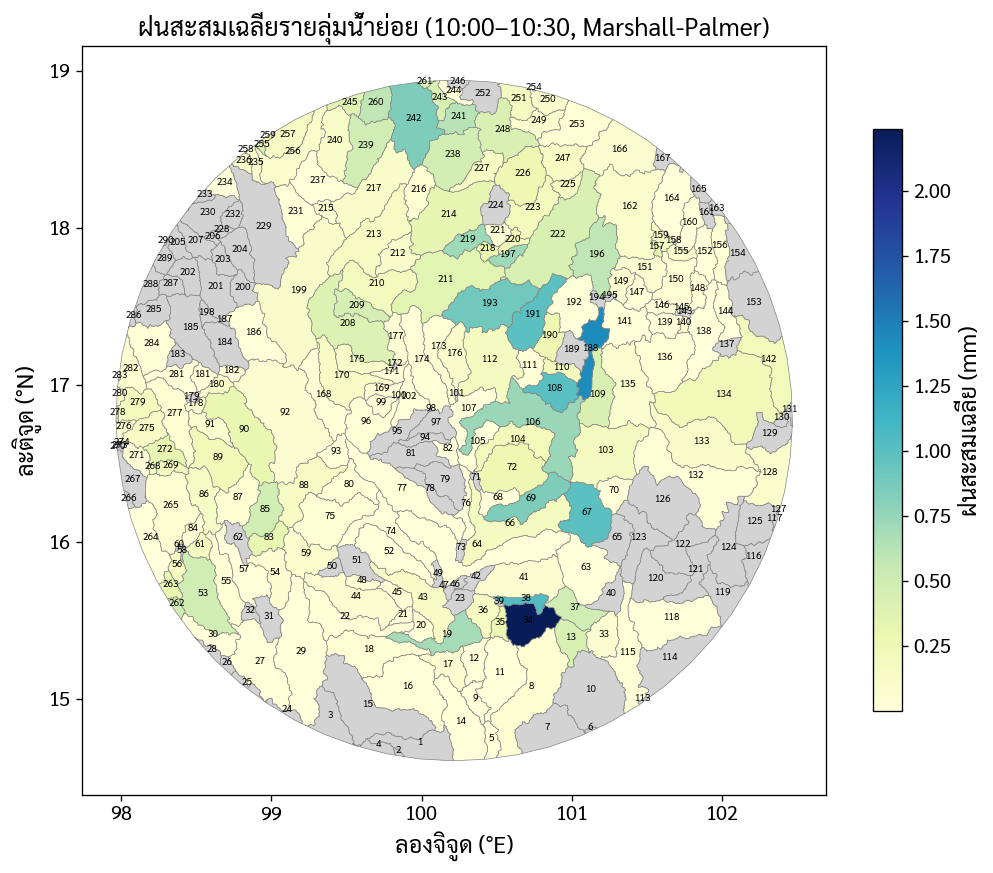

,basin_id,area_km2,rain_mean,rain_max
0,1,791.95,NaN,NaN
1,2,23.70,NaN,NaN
2,3,613.29,NaN,NaN
3,4,145.77,NaN,NaN
4,5,227.12,0.00,0.27
5,6,18.03,NaN,NaN
6,7,1009.53,NaN,NaN
7,8,2178.16,0.06,3.20
8,9,299.61,0.00,0.27
9,10,1907.15,NaN,NaN


In [ ]:
acc_mp = accumulate(*ZR['Marshall-Palmer'])
zs = zonal(acc_mp)
basins['rain_mean'] = [z['mean'] or np.nan for z in zs]
basins['rain_max']  = [z['max']  or np.nan for z in zs]

fig, ax = plt.subplots(figsize=(10, 9))
basins.plot(column='rain_mean', cmap='YlGnBu', legend=True, edgecolor='gray', linewidth=0.4,
            ax=ax, legend_kwds={'label': 'ฝนสะสมเฉลี่ย (mm)', 'shrink': 0.7},
            missing_kwds={'color': 'lightgray', 'label': 'ไม่มีข้อมูล'})
for _, r in basins.iterrows():
    c = r.geometry.centroid
    ax.annotate(str(r['basin_id']), (c.x, c.y), fontsize=6, ha='center')
ax.set_title('ฝนสะสมเฉลี่ยรายลุ่มน้ำย่อย (10:00–10:30, Marshall-Palmer)', fontsize=15)
ax.set_xlabel('ลองจิจูด (°E)'); ax.set_ylabel('ละติจูด (°N)')
fig.savefig(os.path.join(OUT, 'A1_choropleth_rain_mean.png'), dpi=300, bbox_inches='tight')
plt.show()

basins[['basin_id','area_km2','rain_mean','rain_max']].round(2).head(10)

---
## A2 — Cartesian vs Polar: วิธี grid มีผลต่อค่าฝนรายลุ่มน้ำแค่ไหน?

เทียบฝนเฉลี่ยรายลุ่มน้ำที่คำนวณจาก **กริดคาร์ทีเซียน** (สม่ำเสมอ) กับ **จุดโพลาร์ดิบ** (หนาแน่นใกล้สถานี)


In [ ]:
a, b = ZR['Marshall-Palmer']

# คาร์ทีเซียน: อัตราฝน 10:00
R_cart = dbz_to_R(dbz_1000, a, b)
zc = zonal(R_cart, stats=('mean',))
basins['R_cartesian'] = [z['mean'] or np.nan for z in zc]

# โพลาร์: อัตราฝนจาก bin ดิบ (sweep 0) → จุด → sjoin เข้าลุ่มน้ำ
r0 = pyart.io.read(P.RADAR_1000)
sl = r0.get_slice(0)
glon = r0.gate_longitude['data'][sl].ravel()
glat = r0.gate_latitude['data'][sl].ravel()
dbz_p = r0.fields['reflectivity']['data'][sl]
rho_p = r0.fields['cross_correlation_ratio']['data'][sl]
dbz_p = np.ma.masked_where((rho_p < 0.8) | (dbz_p < 0), dbz_p)
Rp = np.ma.filled((10.0**(dbz_p/10.0)/a)**(1.0/b), np.nan).ravel()

pts = gpd.GeoDataFrame({'R': Rp}, geometry=gpd.points_from_xy(glon, glat), crs='EPSG:4326').dropna(subset=['R'])
j = gpd.sjoin(pts, basins[['basin_id','geometry']], predicate='within')
polar_mean = j.groupby('basin_id')['R'].mean()
basins['R_polar'] = basins['basin_id'].map(polar_mean)

basins['diff_pct'] = (basins['R_polar'] - basins['R_cartesian']) / basins['R_cartesian'] * 100
print("ผลต่างเฉลี่ย |polar - cartesian| = %.1f%%" % basins['diff_pct'].abs().mean())
basins[['basin_id','R_cartesian','R_polar','diff_pct']].round(2).dropna().head(10)

ผลต่างเฉลี่ย |polar - cartesian| = 13484.0%


,basin_id,R_cartesian,R_polar,diff_pct
7,8,0.17,2.62,1486.03
12,13,0.40,3.79,837.62
13,14,0.02,1.07,5718.18
15,16,0.04,0.81,2010.39
16,17,0.24,1.13,368.52
17,18,0.13,3.65,2767.60
18,19,0.74,2.08,182.26
19,20,0.07,0.80,1013.90
21,22,0.07,0.84,1164.61
28,29,0.02,0.92,3727.91


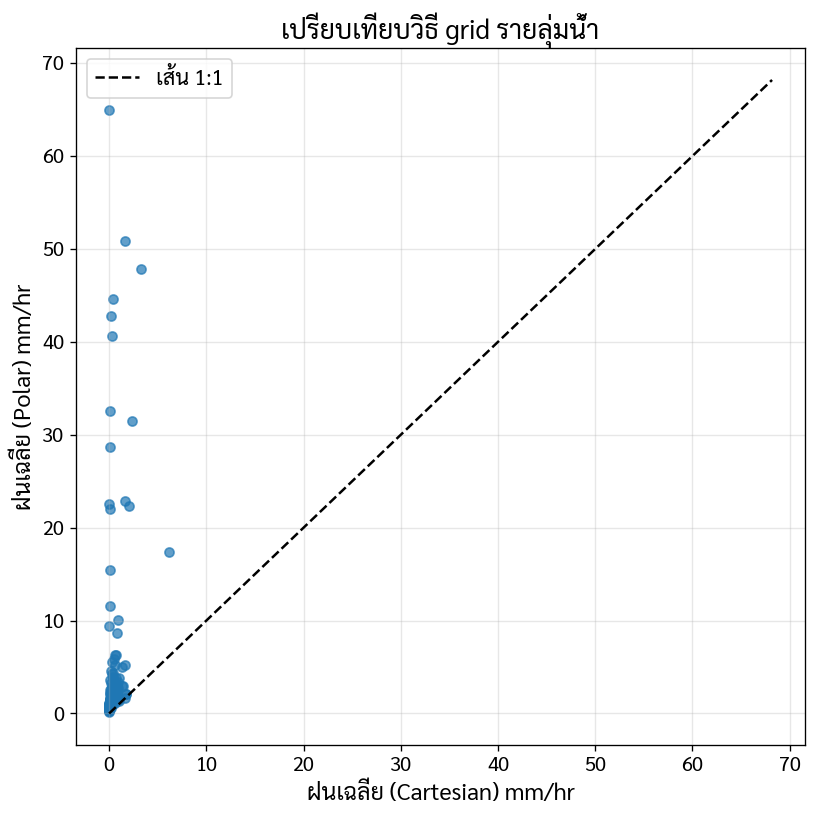

In [ ]:
# กราฟ scatter เทียบสองวิธี
d = basins.dropna(subset=['R_cartesian','R_polar'])
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(d['R_cartesian'], d['R_polar'], s=30, alpha=0.7)
lim = max(d['R_cartesian'].max(), d['R_polar'].max()) * 1.05
ax.plot([0, lim], [0, lim], 'k--', label='เส้น 1:1')
ax.set_xlabel('ฝนเฉลี่ย (Cartesian) mm/hr'); ax.set_ylabel('ฝนเฉลี่ย (Polar) mm/hr')
ax.set_title('เปรียบเทียบวิธี grid รายลุ่มน้ำ'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

---
## A3 — สูตร Z–R: Marshall-Palmer vs Rosenfeld รายลุ่มน้ำ

เขตร้อนควรใช้สูตรใด? เทียบฝนสะสมเฉลี่ยรายลุ่มน้ำจากสองสูตร


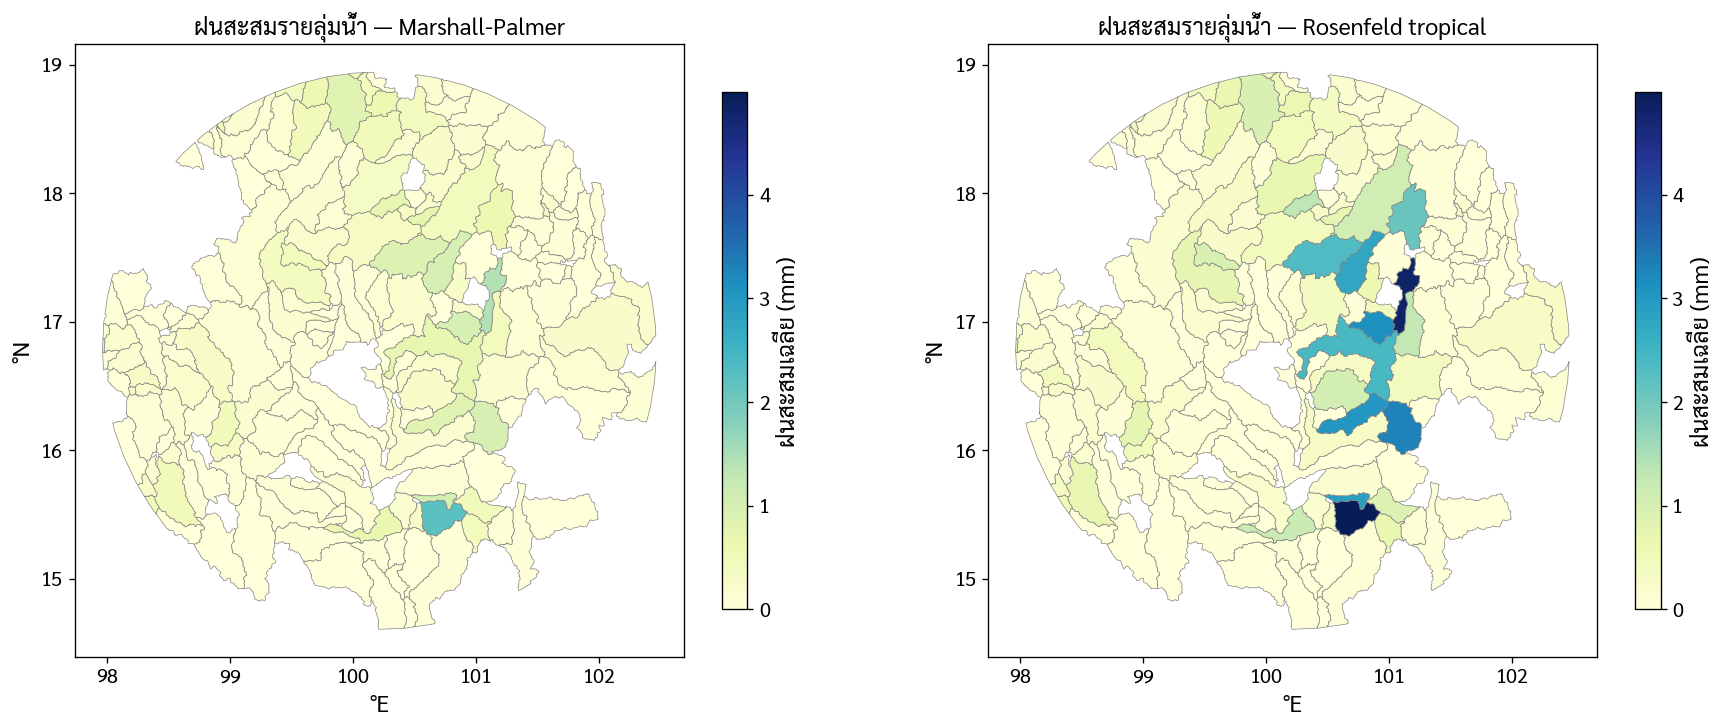

Rosenfeld ให้ฝนมากกว่า MP เฉลี่ย 18.4% ต่อลุ่มน้ำ


In [ ]:
acc_ro = accumulate(*ZR['Rosenfeld tropical'])
basins['rain_MP'] = basins['rain_mean']
basins['rain_RO'] = [z['mean'] or np.nan for z in zonal(acc_ro)]
basins['ZR_diff_pct'] = (basins['rain_RO'] - basins['rain_MP']) / basins['rain_MP'] * 100

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
vmax = np.nanmax([basins['rain_MP'].max(), basins['rain_RO'].max()])
for ax, col, name in zip(axes, ['rain_MP','rain_RO'], ['Marshall-Palmer','Rosenfeld tropical']):
    basins.plot(column=col, cmap='YlGnBu', vmin=0, vmax=vmax, legend=True, edgecolor='gray',
                linewidth=0.4, ax=ax, legend_kwds={'label':'ฝนสะสมเฉลี่ย (mm)','shrink':0.7})
    ax.set_title(f'ฝนสะสมรายลุ่มน้ำ — {name}', fontsize=14)
    ax.set_xlabel('°E'); ax.set_ylabel('°N')
fig.savefig(os.path.join(OUT, 'A3_ZR_compare.png'), dpi=300, bbox_inches='tight')
plt.show()
print(f"Rosenfeld ให้ฝนมากกว่า MP เฉลี่ย {basins['ZR_diff_pct'].mean():.1f}% ต่อลุ่มน้ำ")

---
## A4 — ประยุกต์อุทกวิทยา: ปริมาตรน้ำฝนรายลุ่มน้ำ (ล้าน ม³)

$$\text{ปริมาตร (ม}^3) = \text{ฝนเฉลี่ย (m)} \times \text{พื้นที่ลุ่มน้ำ (m}^2)$$
ใช้ประเมินน้ำท่าที่ไหลลงลุ่มน้ำ — ข้อมูลสำคัญต่อการบริหารเขื่อน/อ่างเก็บน้ำ


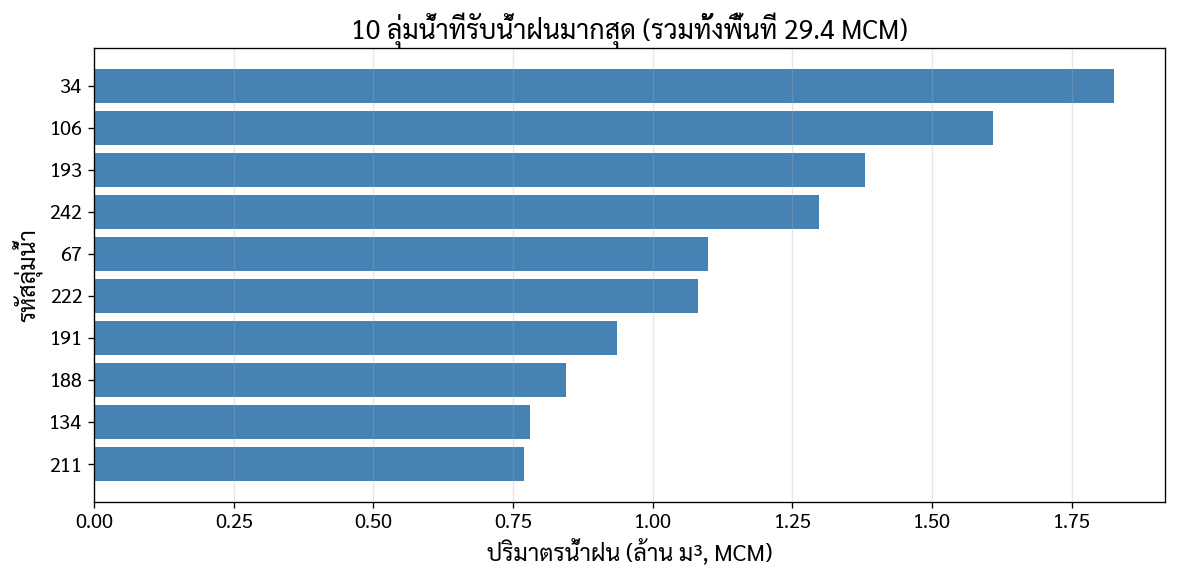

In [ ]:
# ปริมาตร = ฝน(mm)/1000 * พื้นที่(km2)*1e6  -> m3 ; แปลงเป็นล้าน ลบ.ม. (MCM)
basins['volume_MCM'] = (basins['rain_MP']/1000.0) * (basins['area_km2']*1e6) / 1e6
total = basins['volume_MCM'].sum()

top = basins.dropna(subset=['volume_MCM']).nlargest(10, 'volume_MCM')
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top['basin_id'].astype(str), top['volume_MCM'], color='steelblue')
ax.invert_yaxis(); ax.set_xlabel('ปริมาตรน้ำฝน (ล้าน ม³, MCM)')
ax.set_ylabel('รหัสลุ่มน้ำ'); ax.set_title(f'10 ลุ่มน้ำที่รับน้ำฝนมากสุด (รวมทั้งพื้นที่ {total:,.1f} MCM)')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout(); fig.savefig(os.path.join(OUT, 'A4_volume_top10.png'), dpi=300, bbox_inches='tight')
plt.show()

---
## A5 — เตือนภัย: จัดอันดับลุ่มน้ำเสี่ยงน้ำหลาก

จัดอันดับตามฝนสะสมเฉลี่ยและฝนสูงสุด — ลุ่มน้ำที่ฝนหนักและพื้นที่เล็ก มักตอบสนองไว (flash flood)


In [ ]:
risk = basins.dropna(subset=['rain_mean']).copy()
# ดัชนีเสี่ยงอย่างง่าย: ฝนสะสมเฉลี่ย ถ่วงด้วยความเข้มฝนสูงสุด
risk['risk_index'] = risk['rain_mean'] * (risk['rain_max'] / risk['rain_max'].max())
rank = risk.nlargest(10, 'risk_index')[['basin_id','area_km2','rain_mean','rain_max','risk_index']]
print("🔺 10 ลุ่มน้ำเสี่ยงน้ำหลากสูงสุด:")
rank.round(2)

🔺 10 ลุ่มน้ำเสี่ยงน้ำหลากสูงสุด:


,basin_id,area_km2,rain_mean,rain_max,risk_index
66,67,1106.46,0.99,195.46,0.99
68,69,837.61,0.84,124.87,0.54
187,188,593.24,1.42,64.67,0.47
107,108,627.01,1.01,64.67,0.33
190,191,940.76,0.99,60.89,0.31
105,106,2174.25,0.74,79.18,0.30
192,193,1523.84,0.90,62.97,0.29
33,34,816.76,2.24,22.75,0.26
195,196,1145.45,0.59,76.02,0.23
221,222,2492.08,0.43,76.02,0.17


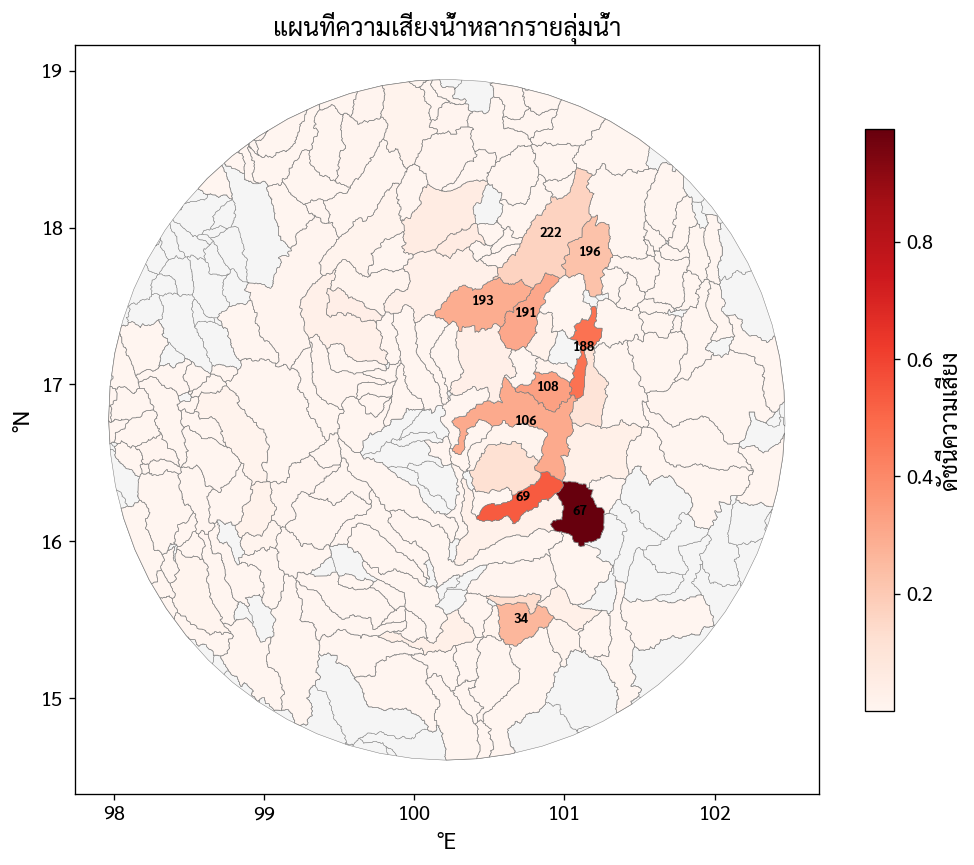

In [ ]:
fig, ax = plt.subplots(figsize=(10, 9))
basins.plot(color='whitesmoke', edgecolor='gray', linewidth=0.3, ax=ax)
risk.plot(column='risk_index', cmap='Reds', legend=True, edgecolor='gray', linewidth=0.4,
          ax=ax, legend_kwds={'label':'ดัชนีความเสี่ยง','shrink':0.7})
for _, r in rank.iterrows():
    c = basins.loc[basins['basin_id']==r['basin_id']].geometry.centroid.iloc[0]
    ax.annotate(str(int(r['basin_id'])), (c.x, c.y), fontsize=8, fontweight='bold', ha='center')
ax.set_title('แผนที่ความเสี่ยงน้ำหลากรายลุ่มน้ำ', fontsize=15)
ax.set_xlabel('°E'); ax.set_ylabel('°N')
fig.savefig(os.path.join(OUT, 'A5_flood_risk.png'), dpi=300, bbox_inches='tight')
plt.show()

---
## A6 — พื้นที่ครอบคลุมฝน: สัดส่วนพื้นที่ลุ่มน้ำที่ฝนตกเกินเกณฑ์

เช่น % ของลุ่มน้ำที่มีอัตราฝน > 10 mm/hr ณ 10:00 — บอกว่าฝน "กระจายทั่ว" หรือ "กระจุกเป็นจุด"


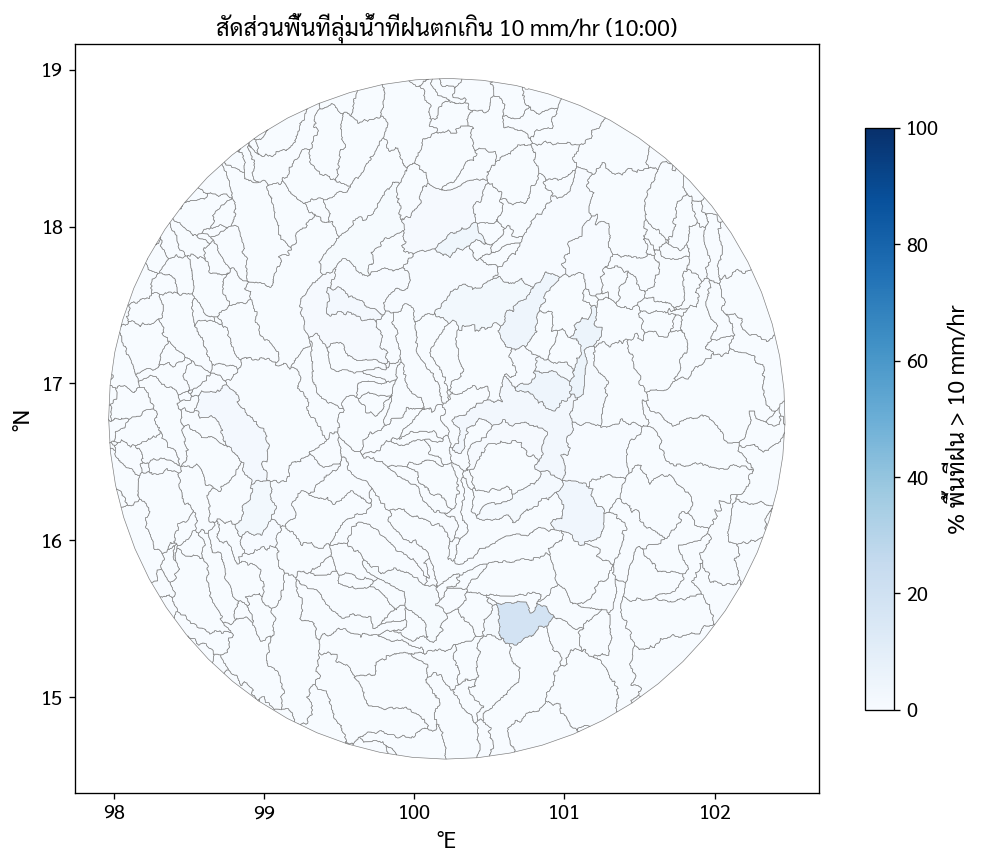

In [ ]:
THRESH = 10.0  # mm/hr
R_now = dbz_to_R(dbz_1000, *ZR['Marshall-Palmer'])
wet = np.where(np.isnan(R_now), np.nan, (R_now > THRESH).astype(float)) * 100.0
basins['coverage_pct'] = [z['mean'] if z['mean'] is not None else np.nan for z in zonal(wet, stats=('mean',))]

fig, ax = plt.subplots(figsize=(10, 9))
basins.plot(column='coverage_pct', cmap='Blues', vmin=0, vmax=100, legend=True,
            edgecolor='gray', linewidth=0.4, ax=ax,
            legend_kwds={'label': f'% พื้นที่ฝน > {THRESH:.0f} mm/hr', 'shrink':0.7})
ax.set_title(f'สัดส่วนพื้นที่ลุ่มน้ำที่ฝนตกเกิน {THRESH:.0f} mm/hr (10:00)', fontsize=14)
ax.set_xlabel('°E'); ax.set_ylabel('°N')
fig.savefig(os.path.join(OUT, 'A6_coverage.png'), dpi=300, bbox_inches='tight')
plt.show()

---
## A7 — คุณภาพข้อมูล: ผลของ Beam Blockage ต่อฝนรายลุ่มน้ำ

บูรณาการบท 11 — ลุ่มน้ำที่อยู่ในทิศที่ลำบีมถูกภูเขาบดบัง อาจ **ประเมินฝนต่ำกว่าจริง** เราคำนวณ CBB เฉลี่ยรายลุ่มน้ำเพื่อ *ตั้งค่าสถานะเตือน*


ลุ่มน้ำที่ถูกบดบังเฉลี่ย > 0.3 (อาจประเมินฝนต่ำ): 64 ลุ่มน้ำ


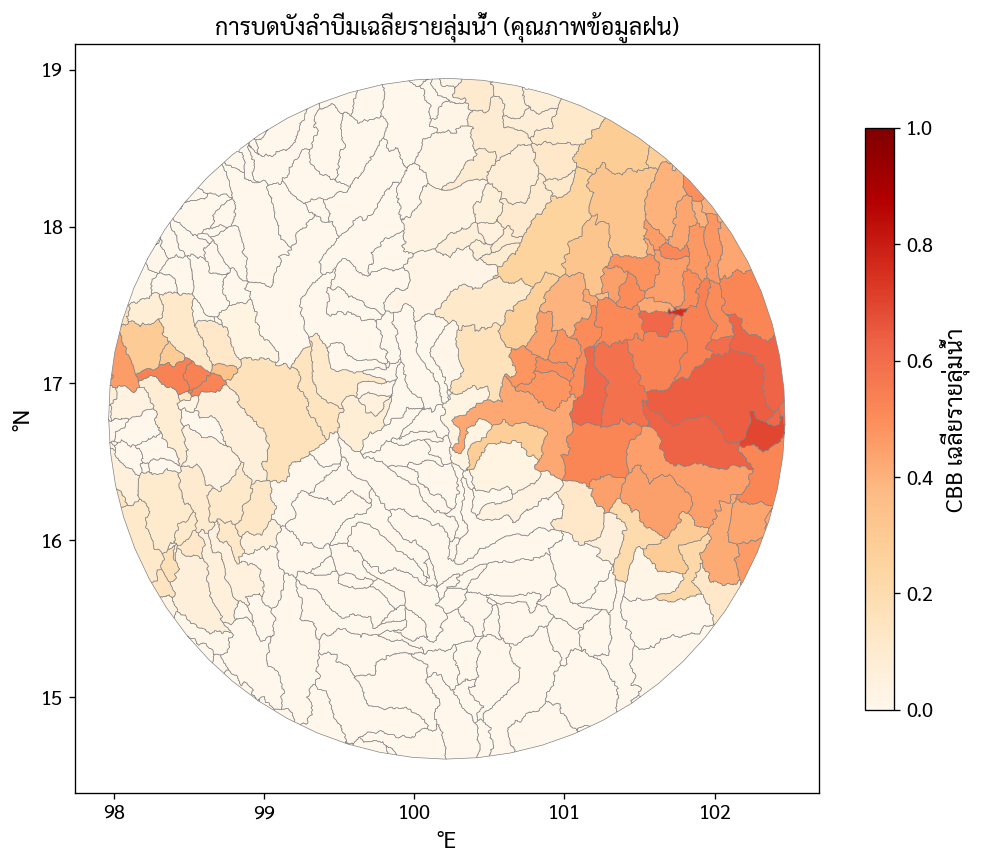

In [ ]:
from pyproj import Geod, Transformer
from scipy.interpolate import griddata

try:
    r0 = pyart.io.read(P.RADAR_1000)
    lon0 = float(r0.longitude['data'][0]); lat0 = float(r0.latitude['data'][0]); alt0 = float(r0.altitude['data'][0])
    elev = float(np.min(r0.fixed_angle['data']))
    geod = Geod(ellps='WGS84')
    az = np.arange(0, 360, 2.0); rr = np.arange(1000, 240000, 2000.0)
    AZ, RR = np.meshgrid(az, rr, indexing='ij')
    lo, la, _ = geod.fwd(np.full(AZ.size, lon0), np.full(AZ.size, lat0), AZ.ravel(), RR.ravel())
    lo = lo.reshape(AZ.shape); la = la.reshape(AZ.shape)
    with rasterio.open(P.DEM) as ds:
        tr = Transformer.from_crs('EPSG:4326', ds.crs if ds.crs else 'EPSG:4326', always_xy=True)
        xx, yy = tr.transform(lo.ravel(), la.ravel())
        terr = np.array([v[0] for v in ds.sample(np.c_[xx, yy])], dtype=float).reshape(AZ.shape)
    terr = np.nan_to_num(np.where(terr < -1000, np.nan, terr), nan=0.0)

    A=6371000.0; KE=4/3
    BH = np.sqrt(rr**2 + (KE*A)**2 + 2*rr*KE*A*np.sin(np.radians(elev))) - KE*A + alt0
    a_rad = rr * np.radians(1.0) / 2.0
    y = terr - BH[None, :]; a2 = np.broadcast_to(a_rad, terr.shape)
    PBB = np.zeros_like(y); PBB[y >= a2] = 1.0
    m = (y > -a2) & (y < a2); ym, am = y[m], a2[m]
    PBB[m] = (ym*np.sqrt(am**2-ym**2) + am**2*np.arcsin(ym/am) + np.pi*am**2/2)/(np.pi*am**2)
    CBB = np.maximum.accumulate(PBB, axis=1)

    # interpolate CBB -> กริดฝน แล้ว zonal
    cbb_grid = griddata(np.c_[lo.ravel(), la.ravel()], CBB.ravel(), (lons, lats), method='linear')
    basins['cbb_mean'] = [z['mean'] if z['mean'] is not None else np.nan
                          for z in zonal(np.where(COVER, cbb_grid, np.nan), stats=('mean',))]
    basins['blocked_flag'] = np.where(basins['cbb_mean'] > 0.3, '⚠️ ประเมินต่ำ', 'ปกติ')
    n_flag = int((basins['cbb_mean'] > 0.3).sum())
    print(f"ลุ่มน้ำที่ถูกบดบังเฉลี่ย > 0.3 (อาจประเมินฝนต่ำ): {n_flag} ลุ่มน้ำ")

    fig, ax = plt.subplots(figsize=(10, 9))
    basins.plot(column='cbb_mean', cmap='OrRd', vmin=0, vmax=1, legend=True, edgecolor='gray',
                linewidth=0.4, ax=ax, legend_kwds={'label':'CBB เฉลี่ยรายลุ่มน้ำ','shrink':0.7})
    ax.set_title('การบดบังลำบีมเฉลี่ยรายลุ่มน้ำ (คุณภาพข้อมูลฝน)', fontsize=14)
    ax.set_xlabel('°E'); ax.set_ylabel('°N')
    fig.savefig(os.path.join(OUT, 'A7_beam_blockage_basin.png'), dpi=300, bbox_inches='tight')
    plt.show()
except Exception as e:
    print("ข้ามการวิเคราะห์ beam blockage (ตรวจ DEM/หน่วยความจำ):", repr(e))
    basins['cbb_mean'] = np.nan; basins['blocked_flag'] = 'n/a'

---
## A8 — เชิงเวลา: การเปลี่ยนแปลงฝน 10:00 → 10:30 รายลุ่มน้ำ

ลุ่มน้ำใดฝน **ทวีความรุนแรง** (ควรจับตา) หรือ **อ่อนกำลัง**


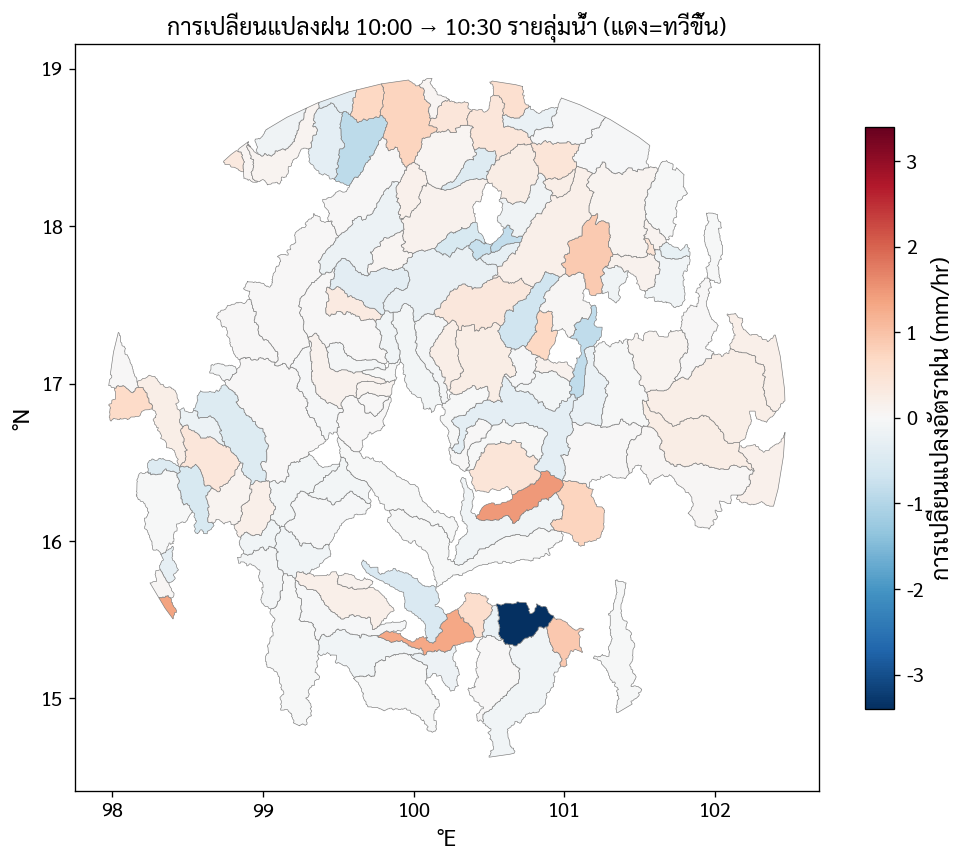

ลุ่มน้ำที่ฝนทวีขึ้นมากสุด:
 basin_id  R_1000  R_1030  R_change
       69    0.95    2.42      1.48
      262    0.32    1.70      1.38
       19    0.74    2.04      1.30
       13    0.40    1.33      0.93
      196    0.73    1.62      0.89


In [ ]:
a, b = ZR['Marshall-Palmer']
basins['R_1000'] = [z['mean'] or np.nan for z in zonal(dbz_to_R(dbz_1000, a, b), stats=('mean',))]
basins['R_1030'] = [z['mean'] or np.nan for z in zonal(dbz_to_R(dbz_1030, a, b), stats=('mean',))]
basins['R_change'] = basins['R_1030'] - basins['R_1000']

fig, ax = plt.subplots(figsize=(10, 9))
vmax = np.nanmax(np.abs(basins['R_change']))
basins.plot(column='R_change', cmap='RdBu_r', vmin=-vmax, vmax=vmax, legend=True,
            edgecolor='gray', linewidth=0.4, ax=ax,
            legend_kwds={'label':'การเปลี่ยนแปลงอัตราฝน (mm/hr)','shrink':0.7})
ax.set_title('การเปลี่ยนแปลงฝน 10:00 → 10:30 รายลุ่มน้ำ (แดง=ทวีขึ้น)', fontsize=14)
ax.set_xlabel('°E'); ax.set_ylabel('°N')
fig.savefig(os.path.join(OUT, 'A8_temporal_change.png'), dpi=300, bbox_inches='tight')
plt.show()

worsen = basins.dropna(subset=['R_change']).nlargest(5, 'R_change')[['basin_id','R_1000','R_1030','R_change']]
print("ลุ่มน้ำที่ฝนทวีขึ้นมากสุด:"); print(worsen.round(2).to_string(index=False))

---
## A9 — การจำแนกระดับเตือนภัย: เขียว / เหลือง / แดง

จัดระดับตามฝนสะสม (ตัวอย่างเกณฑ์: <10 เขียว, 10–25 เหลือง, >25 mm แดง) — ปรับเกณฑ์ให้เหมาะกับพื้นที่จริงได้


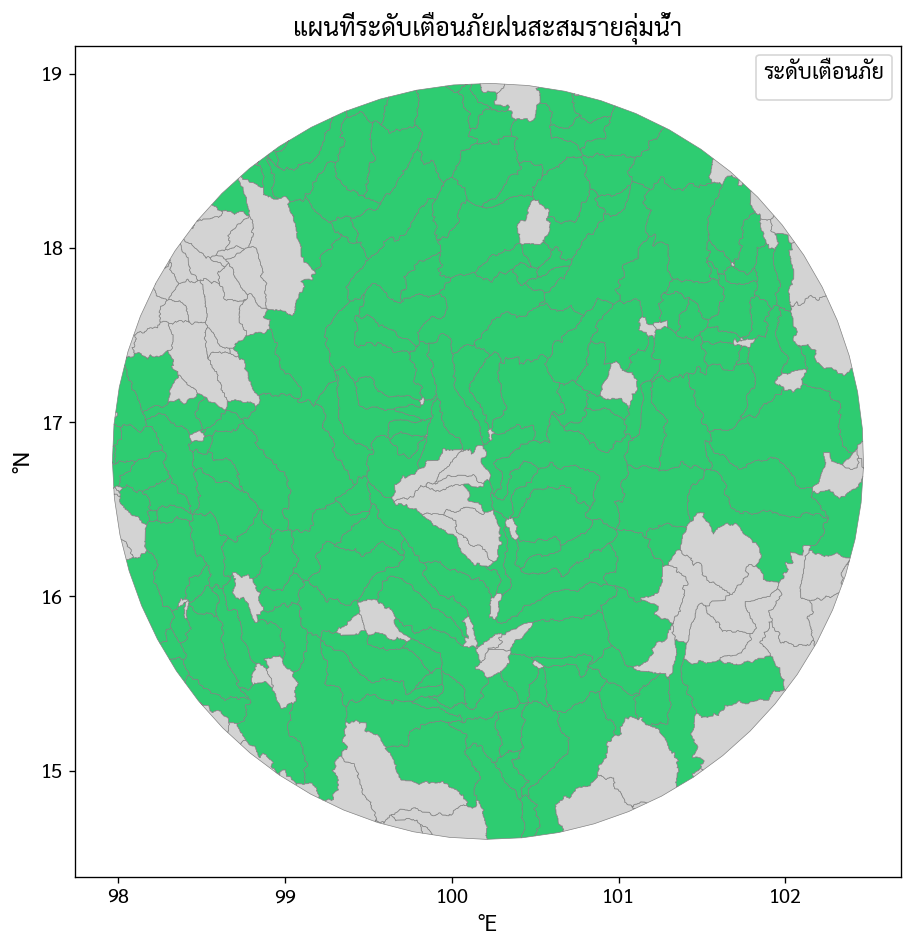

warn
🟢 เขียว        186
ไม่มีข้อมูล    104


In [ ]:
def warn_level(mm):
    if np.isnan(mm): return 'ไม่มีข้อมูล'
    if mm < 10:  return '🟢 เขียว'
    if mm < 25:  return '🟡 เหลือง'
    return '🔴 แดง'

basins['warn'] = basins['rain_MP'].apply(warn_level)
cmap_warn = {'🟢 เขียว':'#2ecc71','🟡 เหลือง':'#f1c40f','🔴 แดง':'#e74c3c','ไม่มีข้อมูล':'lightgray'}

fig, ax = plt.subplots(figsize=(10, 9))
for lvl, col in cmap_warn.items():
    sub = basins[basins['warn'] == lvl]
    if len(sub): sub.plot(color=col, edgecolor='gray', linewidth=0.4, ax=ax, label=lvl)
ax.legend(title='ระดับเตือนภัย', fontsize=11)
ax.set_title('แผนที่ระดับเตือนภัยฝนสะสมรายลุ่มน้ำ', fontsize=15)
ax.set_xlabel('°E'); ax.set_ylabel('°N')
fig.savefig(os.path.join(OUT, 'A9_warning_levels.png'), dpi=300, bbox_inches='tight')
plt.show()
print(basins['warn'].value_counts().to_string())

---
## A10 — รายงานสรุป และส่งออกผลลัพธ์ (CSV / GeoJSON / PNG)

รวมทุกตัวชี้วัดเป็นตารางเดียว แล้วส่งออกให้นำไปใช้ต่อ (Excel, QGIS, รายงาน)


In [ ]:
cols = ['basin_id','area_km2','rain_MP','rain_RO','rain_max','volume_MCM',
        'coverage_pct','cbb_mean','blocked_flag','R_change','warn']
report = basins[cols].copy().round(2)

# ส่งออก CSV และ GeoJSON (เขียนลงเครื่องก่อน แล้วคัดลอกขึ้น Drive)
csv_local = '/content/basin_report.csv'; geo_local = '/content/basin_report.geojson'
report.to_csv(csv_local, index=False, encoding='utf-8-sig')
basins[cols + ['geometry']].to_file(geo_local, driver='GeoJSON')
shutil.copy(csv_local, os.path.join(OUT, 'basin_report.csv'))
shutil.copy(geo_local, os.path.join(OUT, 'basin_report.geojson'))
print("ส่งออกแล้ว: basin_report.csv, basin_report.geojson →", OUT)

print("\n📋 ตัวอย่างตารางสรุปสถานการณ์ฝนรายลุ่มน้ำ:")
report.sort_values('rain_MP', ascending=False).head(12)

ส่งออกแล้ว: basin_report.csv, basin_report.geojson → /content/drive/MyDrive/tmd_radar_course/1results/lesson12

📋 ตัวอย่างตารางสรุปสถานการณ์ฝนรายลุ่มน้ำ:


,basin_id,area_km2,rain_MP,rain_RO,rain_max,volume_MCM,coverage_pct,cbb_mean,blocked_flag,R_change,warn
33,34,816.76,2.24,4.99,22.75,1.83,18.46,0.00,ปกติ,-3.40,🟢 เขียว
187,188,593.24,1.42,4.83,64.67,0.84,5.86,0.51,⚠️ ประเมินต่ำ,-0.88,🟢 เขียว
37,38,229.90,1.05,2.88,24.60,0.24,0.00,0.00,ปกติ,NaN,🟢 เขียว
107,108,627.01,1.01,3.10,64.67,0.63,4.99,0.48,⚠️ ประเมินต่ำ,-0.10,🟢 เขียว
66,67,1106.46,0.99,3.31,195.46,1.10,3.53,0.12,ปกติ,0.75,🟢 เขียว
190,191,940.76,0.99,2.78,60.89,0.94,4.53,0.28,ปกติ,-0.68,🟢 เขียว
192,193,1523.84,0.90,2.34,62.97,1.38,2.60,0.12,ปกติ,0.39,🟢 เขียว
241,242,1533.61,0.85,0.97,3.10,1.30,0.00,0.00,ปกติ,0.75,🟢 เขียว
68,69,837.61,0.84,3.00,124.87,0.71,1.82,0.04,ปกติ,1.48,🟢 เขียว
105,106,2174.25,0.74,2.42,79.18,1.61,2.74,0.43,⚠️ ประเมินต่ำ,-0.34,🟢 เขียว


## 📝 แบบฝึกหัด (Capstone)

1. เลือก **ลุ่มน้ำที่สนใจ 1 แห่ง** (จาก `basin_id`) แล้วรายงานครบ: ฝนเฉลี่ย MP vs Rosenfeld ต่างกันกี่ %, ปริมาตรน้ำ (MCM), ระดับเตือนภัย, และถูกบดบังหรือไม่
2. เปลี่ยน **เกณฑ์เตือนภัย** (A9) และ **เกณฑ์ครอบคลุมฝน** (A6) ให้เหมาะกับเกณฑ์ของกรมอุตุฯ/กรมชลฯ แล้วดูจำนวนลุ่มน้ำแต่ละระดับ
3. วิเคราะห์: การเลือก **สูตร Z–R** และ **วิธี grid (Cartesian/Polar)** ทำให้ **ปริมาตรน้ำรวม** ของพื้นที่ต่างกันกี่ % — มีนัยต่อการบริหารน้ำอย่างไร?
4. (ต่อยอด) ถ้ามีข้อมูลหลายช่วงเวลา ลองทำฝนสะสมรายชั่วโมง/รายวัน แล้วทำ zonal statistics เชิงเวลา


In [ ]:
# แบบฝึกหัดข้อ 1 (โครงเริ่มต้น): รายงานลุ่มน้ำเดียว
bid = int(basins.loc[basins['rain_MP'].idxmax(), 'basin_id'])   # เลือกลุ่มน้ำฝนมากสุดเป็นตัวอย่าง
row = report[report['basin_id'] == bid].iloc[0]
print(f"===== รายงานลุ่มน้ำรหัส {bid} =====")
print(f"พื้นที่           : {row['area_km2']:.1f} กม².")
print(f"ฝนสะสม MP/Rosenfeld: {row['rain_MP']:.1f} / {row['rain_RO']:.1f} mm")
print(f"ปริมาตรน้ำ         : {row['volume_MCM']:.2f} ล้าน ม³")
print(f"ระดับเตือนภัย       : {row['warn']}")
print(f"สถานะการบดบัง       : {row['blocked_flag']} (CBB={row['cbb_mean']})")
# TODO (นิสิต): เปลี่ยน bid เป็นลุ่มน้ำที่สนใจ แล้ววิเคราะห์ข้อ 2–4 ต่อ

===== รายงานลุ่มน้ำรหัส 34 =====
พื้นที่           : 816.8 กม².
ฝนสะสม MP/Rosenfeld: 2.2 / 5.0 mm
ปริมาตรน้ำ         : 1.83 ล้าน ม³
ระดับเตือนภัย       : 🟢 เขียว
สถานะการบดบัง       : ปกติ (CBB=0.0)


---
## 🎯 สรุป (Capstone)

บทนี้บูรณาการทั้งหลักสูตรเข้าด้วยกัน จากการอ่านเรดาร์ดิบสู่ **สารสนเทศพร้อมใช้รายลุ่มน้ำ**:
- **Zonal statistics** สรุปฝนเรดาร์รายลุ่มน้ำได้ทั้งบนกริด Cartesian และ Polar (ให้ค่าต่างกัน)
- การเลือก **สูตร Z–R** ส่งผลต่อฝน/ปริมาตรน้ำรายลุ่มน้ำอย่างมีนัย (เขตร้อน → Rosenfeld)
- ประยุกต์ได้จริงหลายด้าน: **ปริมาตรน้ำ, การจัดอันดับเสี่ยงน้ำหลาก, พื้นที่ครอบคลุมฝน, การเตือนภัย**
- ต้องคำนึงถึง **คุณภาพข้อมูล** (beam blockage บท 11) ก่อนตีความ
- ผลลัพธ์ส่งออกเป็น CSV/GeoJSON/แผนที่ เพื่อใช้ต่อใน Excel/QGIS/รายงาน

🎓 **ยินดีด้วย! นิสิตได้เดินทางครบตั้งแต่การอ่านสัญญาณเรดาร์ จนถึงการผลิตสารสนเทศเชิงพื้นที่เพื่อการตัดสินใจ**
